# Module 1: Your First Credit Risk Model with NEXUS

**Workshop Track:** 100-Level | Introduction
**Prerequisites:** Python 3.10+, NEXUS API key, Module 0 completed

---

Welcome to Module 1 of the NEXUS onboarding workshop. In Module 0 you saw the core idea — training a model on historical data to predict outcomes for inputs you have never seen. Now we apply that idea to a real problem.

Over the next nine modules, we take you from your first prediction all the way through a production-grade credit risk pipeline on AWS. Each module builds on the last, so by Module 8 you have a complete, battle-tested workflow to bring back to your team.

This module is deliberately simple. The goal is a successful `fit()` and `predict()` in under 45 minutes using a real credit risk dataset. By the end, you will have trained a binary classifier to predict loan default and understand exactly what NEXUS is doing while you wait.

Let's get into it.

## Learning Objectives

By the end of this notebook you will:

- Have NEXUS installed and authenticated on your machine
- Understand what makes NEXUS different from a local sklearn model
- Know exactly what data format NEXUS expects
- Have trained your first `NEXUSClassifier` model and generated real predictions
- Know how to persist your model using `trained_model_id_` so you never have to retrain unnecessarily

---


## The Business Problem

A lender has to decide, from limited data, whether an applicant will pay the loan back. Our dataset holds **4,591 historical borrowers** — age, employment history, branch proximity, prior lenders — and whether each ultimately defaulted. The job: score a new applicant's default risk before the bank commits a dollar.

In Module 1, we start with four numeric features to keep this first model simple. NEXUS also accepts categorical columns as-is (and a date converts to one simple numeric feature), so in Module 3 we add those columns and join additional data sources to build a materially better model.

---

In [ ]:
# ============================================================================
# Workshop bootstrap — run this first. Safe to re-run. Identical in every module.
#
# In Google Colab, add two secrets via the key icon in the left sidebar
# (toggle "Notebook access" on for each):
#   • FUNDAMENTAL_API_KEY            — your NEXUS API key (ak_...)
#   • CLOUDSMITH_FUNDAMENTAL_TOKEN   — token to install the Fundamental SDK
#
# Each Colab notebook runs in its own fresh VM, so the modules share state
# (model IDs, feature lists) through a small JSON file on your Google Drive.
# This cell asks to mount Drive — approve the popup. If you decline, later
# modules will ask you to paste the values printed by earlier ones instead.
# See README.md for details.
# ============================================================================
import os, sys, json, subprocess
from pathlib import Path

# TODO at go-live: switch REPO to "Fundamental-Technologies/introduction-to-nexus"
REPO = "jawhnycooke/nexus_onboarding_workshop"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- Dataset -----------------------------------------------------------------
# In Colab we sparse-fetch ONLY the dataset folder; the notebook itself is
# loaded straight from GitHub by Colab, so nothing else is needed on disk.
if IN_COLAB:
    _data_repo = Path("/content/workshop_data")
    DATASET_DIR = _data_repo / "dataset"
    if not DATASET_DIR.is_dir():
        print("Fetching the workshop dataset…")
        subprocess.run(["git", "clone", "--quiet", "--depth", "1", "--filter=blob:none",
                        "--sparse", f"https://github.com/{REPO}.git", str(_data_repo)],
                       check=True)
        subprocess.run(["git", "-C", str(_data_repo), "sparse-checkout", "set", "dataset"],
                       check=True)
    WORKSHOP_ROOT = Path("/content")
else:
    # Locally the notebooks live in workshop_colab/ inside the cloned repo,
    # and the dataset sits at the repo root.
    _here = Path.cwd().resolve()
    _repo_root = next((p for p in [_here, *_here.parents]
                       if (p / "workshop_colab").is_dir() and (p / "dataset").is_dir()), None)
    if _repo_root is None:
        raise RuntimeError(
            "Could not locate the repository root. Launch Jupyter from inside the "
            "cloned repository so the dataset/ folder can be found."
        )
    DATASET_DIR = _repo_root / "dataset"
    WORKSHOP_ROOT = _repo_root / "workshop_colab"

os.chdir(WORKSHOP_ROOT)

# --- Cross-module state ------------------------------------------------------
# Model IDs and the selected feature list pass between modules through one JSON
# file. In Colab it lives on your Google Drive so it survives across notebooks.
_DRIVE_MOUNTED = False
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        _state_dir = Path("/content/drive/MyDrive/nexus_workshop")
        _state_dir.mkdir(parents=True, exist_ok=True)
        STATE_FILE = _state_dir / "_workshop_state.json"
        _DRIVE_MOUNTED = True
    except Exception as _e:
        print(f"Google Drive not mounted ({_e}).")
        print("State will NOT persist between notebooks — later modules will ask "
              "you to paste the values printed by earlier ones.")
        STATE_FILE = Path("/content/_workshop_state.json")
else:
    STATE_FILE = WORKSHOP_ROOT / "_workshop_state.json"


def save_state(key, value):
    state = json.loads(STATE_FILE.read_text()) if STATE_FILE.exists() else {}
    state[key] = value
    STATE_FILE.write_text(json.dumps(state, indent=2))
    print(f"Saved '{key}' = {value!r}")
    if IN_COLAB and not _DRIVE_MOUNTED:
        print("  (Drive is not mounted — copy this value; the next module will ask for it.)")


def load_state(key, default=None):
    if STATE_FILE.exists():
        return json.loads(STATE_FILE.read_text()).get(key, default)
    return default


def require_state(key, produced_by):
    val = load_state(key)
    if val is None:
        print(f"'{key}' was not found in the workshop state file ({STATE_FILE}).")
        print(f"It is produced by {produced_by}. If you ran that module without "
              "mounting Drive, paste the value it printed.")
        val = input(f"Paste {key} (or press Enter to abort): ").strip().strip("'\"")
        if not val:
            raise RuntimeError(
                f"'{key}' unavailable. Run {produced_by} first (approving the Drive "
                "mount), or re-run this cell and paste the printed value. See README.md."
            )
        save_state(key, val)
    return val


def _get_secret(name, required=True):
    val = os.getenv(name)
    if not val and IN_COLAB:
        try:
            from google.colab import userdata
            val = userdata.get(name)
        except Exception:
            val = None
    if required and not val:
        raise RuntimeError(
            f"Missing secret '{name}'.\n"
            "  • In Colab: open the key icon (Secrets) in the left sidebar, add a "
            f"secret named '{name}', and turn on 'Notebook access'.\n"
            f"  • Locally: export {name} in your shell before launching Jupyter.\n"
            "See README.md for details."
        )
    return val


# --- SDK install (Colab only; locally the SDK is installed during setup).
# Colab already ships pandas, numpy, scikit-learn, matplotlib and xgboost,
# so the Fundamental SDK is the only package to install.
try:
    import fundamental  # noqa: F401
except ImportError:
    if not IN_COLAB:
        raise RuntimeError(
            "Fundamental SDK not found. Install it locally (see README.md) before running."
        )
    _token = _get_secret("CLOUDSMITH_FUNDAMENTAL_TOKEN")
    print("Installing the Fundamental SDK…")
    _index = f"https://dl.cloudsmith.io/{_token}/fundamental/fundamental-client/python/simple/"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "fundamental-client==0.10.0", "--extra-index-url", _index], check=True)

# --- Authentication ---
FUNDAMENTAL_API_KEY = _get_secret("FUNDAMENTAL_API_KEY")
os.environ["FUNDAMENTAL_API_KEY"] = FUNDAMENTAL_API_KEY

from fundamental import Fundamental, NEXUSClassifier, NEXUSRegressor, set_client
client = Fundamental()
set_client(client)

print(f"Workshop ready. Dataset: {DATASET_DIR}")
print(f"State file: {STATE_FILE}"
      + ("" if _DRIVE_MOUNTED or not IN_COLAB else "  (not persistent — Drive not mounted)"))
print(f"API key prefix: {FUNDAMENTAL_API_KEY[:8]}…")


## Authentication

The **workshop bootstrap** cell above already handled authentication. On Google Colab it reads your `FUNDAMENTAL_API_KEY` from Colab Secrets; locally it reads it from your environment. Either way, the SDK is now authenticated and ready — no per-module key handling required.

```bash
# In production you would set the key as an environment variable and the SDK
# picks it up automatically:
export FUNDAMENTAL_API_KEY="your-api-key-here"
```

## What is NEXUS?

NEXUS is Fundamental's **Large Tabular Model (LTM)**. Think of it the way you would think of a large language model like GPT, but instead of being pre-trained on text, it was pre-trained on a massive corpus of tabular datasets. When you call `fit()`, NEXUS adapts to your data. You get a model in minutes, and it works even with small datasets.

**For data scientists:** the interface is identical to scikit-learn. If you know `RandomForestClassifier`, you already know `NEXUSClassifier`. The difference is *where* the computation happens and *what comes out the other side*.

| | scikit-learn | NEXUS |
|---|---|---|
| Training location | Your machine | Fundamental's cloud |
| Model selection | You choose | NEXUS selects automatically |
| Hyperparameter tuning | You tune (GridSearch, etc.) | No hyperparameters to tune |
| Feature engineering | You design | NEXUS learns representations |
| Interface | `fit` / `predict` | `fit` / `predict` (identical) |

**For full-stack engineers:** think of NEXUS as a managed ML API. You POST training data, poll for completion, and call a prediction endpoint, all wrapped behind the same sklearn interface the data science team uses. We expose the raw async submit/poll pattern in Module 5.

A useful analogy: if sklearn is cooking in your own kitchen, NEXUS is calling on a world-class chef. You hand over the same recipe card (your data), and you get back a finished dish (a trained model). The ordering interface looks identical, but what happens in between is fundamentally different.

---


## NEXUS Data Requirements

**Already comfortable with model-input formats?** Skip ahead to Loading the Data.

Before we load our data, a quick look at what NEXUS accepts:

| Data Type | Supported in `X`? |
|-----------|-----------------|
| `int64`, `float64` | Yes |
| `bool` | Yes — treated as 0/1 |
| `NaN` / `null` values | Yes — handled natively |
| `object` / `str` (categorical) | Yes — pass them as-is |
| Date columns | Convert to a numeric feature first (Module 3 shows the one-line derivation) |

NEXUS accepts numeric, boolean, and categorical (string) columns directly in a DataFrame or numpy array. Missing values are handled natively, and categorical columns are encoded automatically — so cleaning and encoding are optional. They can add signal (less work, not zero), but they are not required before `fit()`. Datetime columns are the one unsupported type: a date column is converted to a simple numeric feature first (Module 3 shows this).

**For this first model, we start with four numeric features to keep things simple.** This keeps the focus on the core `fit` / `predict` loop. In Module 3, we bring in the categorical columns and the date column to add signal.

---

## Loading the Data

Two CSV files: **`borrowers_train.csv`** is what the model sees during `fit()`; **`borrowers_holdout.csv`** stays unseen until evaluation, simulating next month's applicants. Run the cell below to load both and confirm their shapes.

In [2]:
import pandas as pd

# Load the training set and the holdout set
train_df   = pd.read_csv(DATASET_DIR / "credit_risk/borrowers_train.csv")
holdout_df = pd.read_csv(DATASET_DIR / "credit_risk/borrowers_holdout.csv")

print(f"Training set:  {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
print(f"Holdout set:   {holdout_df.shape[0]:,} rows, {holdout_df.shape[1]} columns")
print()
print("Column dtypes:")
print(train_df.dtypes)

Training set:  4,591 rows, 13 columns
Holdout set:   1,149 rows, 13 columns

Column dtypes:
borrower_id                     int64
first_name                     object
last_name                      object
age                             int64
gender                         object
marital_status                 object
distance_from_branch_miles      int64
education_level                object
occupation_sector              object
num_previous_lenders            int64
total_employment_years        float64
account_open_date              object
default_flag                    int64
dtype: object


### Exploring the Target Variable

Our target is `default_flag`: `1` if the borrower defaulted, `0` if they did not.

Before building any model, it is worth understanding the class balance in your training data. A severe imbalance (for example, 99% non-default, 1% default) changes how you should interpret accuracy metrics and may require additional handling. Let's see what we are working with.


In [3]:
# Understand the target distribution before modeling
target_counts = train_df["default_flag"].value_counts()
default_rate  = train_df["default_flag"].mean()

print("Target distribution (training set):")
print(f"  No default (0): {target_counts.get(0, 0):,}")
print(f"  Default    (1): {target_counts.get(1, 0):,}")
print(f"  Default rate:   {default_rate:.1%}")
print()

# Quick look at the numeric columns we will use
numeric_cols = ["age", "distance_from_branch_miles",
                "num_previous_lenders", "total_employment_years"]
print("Numeric feature summary:")
train_df[numeric_cols].describe().round(2)


Target distribution (training set):
  No default (0): 3,713
  Default    (1): 878
  Default rate:   19.1%

Numeric feature summary:


,age,distance_from_branch_miles,num_previous_lenders,total_employment_years
count,4591.00,4591.00,4591.00,4591.00
mean,35.99,9.17,2.68,11.88
std,9.15,8.11,2.49,8.14
min,16.00,1.00,0.00,0.00
25%,29.00,2.00,1.00,6.00
50%,35.00,7.00,2.00,10.00
75%,42.00,14.00,4.00,16.00
max,60.00,29.00,9.00,44.00


**This is class imbalance.** About four out of five borrowers do not default, so a model can score high accuracy while learning very little. Keep that in mind when you read the evaluation numbers below — accuracy alone is misleading here; precision, recall, and ROC AUC carry the real story.

## Selecting Features for Module 1

Our dataset has 13 columns, but several are non-numeric or purely identifiers:

| Column | Type | Module 1? |
|--------|------|-----------|
| `borrower_id` | ID | Drop |
| `first_name`, `last_name` | String | Drop |
| `age` | int | **Use** |
| `gender` | String (categorical) | Module 3 |
| `marital_status` | String (categorical) | Module 3 |
| `distance_from_branch_miles` | int | **Use** |
| `education_level` | String (categorical) | Module 3 |
| `occupation_sector` | String (categorical) | Module 3 |
| `num_previous_lenders` | int | **Use** |
| `total_employment_years` | float | **Use** |
| `account_open_date` | Date string | Module 3 |
| `default_flag` | int (target) | **Target** |

Four clean numeric features. Let's see what NEXUS does with them.


### What This Cell Does

The cell below builds the four objects that every sklearn-style model expects:

| Variable | Shape | What it is |
|----------|-------|------------|
| `X_train` | (4591, 4) | Feature matrix for training — rows are borrowers, columns are features |
| `y_train` | (4591,) | Target vector for training — one label per borrower |
| `X_holdout` | (n, 4) | Feature matrix for evaluation — borrowers the model will never see during training |
| `y_holdout` | (n,) | True labels for the holdout set — used only after predictions are made |

**Why keep the holdout set separate?** A model that memorizes the training data but fails on new borrowers is useless in a real lending workflow. By evaluating on data the model has never seen, we get an honest picture of how it would perform on the next batch of incoming applicants.

After running this cell, check the output to confirm our four numeric columns are present. We are deliberately keeping it simple here — Module 3 adds the categorical and date columns.

In [4]:
# Define the features we are using in Module 1
NUMERIC_FEATURES = [
    "age",
    "distance_from_branch_miles",
    "num_previous_lenders",
    "total_employment_years",
]
TARGET = "default_flag"

# Build feature matrices and target vectors
X_train   = train_df[NUMERIC_FEATURES]
y_train   = train_df[TARGET]

X_holdout = holdout_df[NUMERIC_FEATURES]
y_holdout = holdout_df[TARGET]

print(f"X_train shape:   {X_train.shape}")
print(f"X_holdout shape: {X_holdout.shape}")
print()
print("The four features we use for this simple first model:")
print(X_train.dtypes)


X_train shape:   (4591, 4)
X_holdout shape: (1149, 4)

The four features we use for this simple first model:
age                             int64
distance_from_branch_miles      int64
num_previous_lenders            int64
total_employment_years        float64
dtype: object


## Training Your First Model

### What `fit()` Actually Does

The call below looks identical to sklearn, but under the hood it runs a distinct lifecycle:

```
Your Code           NEXUS SDK            Fundamental API
────────────────────────────────────────────────────────────
nexus.fit(X, y)  →  Validate & serialize X, y
                    Upload dataset       →   Receive & validate
                                             Queue training job
                    Poll for status  ←       Training running...
                                             Training complete
                    Download result  ←       Return trained_model_id
nexus.trained_model_id_ ← Store model ID
```

Two things to hold onto before you run this:

1. **Your model does not live on your machine.** It lives in Fundamental's model registry. `trained_model_id_` is your permanent handle to it — we will save it right after training completes.
2. **Training takes a moment.** NEXUS is optimizing for predictive performance, not raw speed. On the credit-risk dataset, a quality-mode fit usually finishes in a minute or two; larger datasets stretch that window.


### Understanding `mode="quality"`

`NEXUSClassifier` accepts a `mode` parameter on the constructor that controls the training strategy:

| Mode | What it does | When to use it |
|------|-------------|----------------|
| `"quality"` | Explores more model configurations, takes longer | Final models, production scoring |
| `"speed"` | Returns faster with a leaner training run | Prototyping, quick iteration |

We are using `"quality"` here because we want to see what NEXUS is actually capable of on this dataset. In Module 2, we run both modes side-by-side and compare the performance difference on real data.

**Go ahead and run the next cell.** Training will take a minute or two. The SDK will print a confirmation when it is done.


In [5]:
# Initialize the classifier
# mode is set on the constructor. mode="quality" optimizes for
# predictive performance over training speed.
nexus = NEXUSClassifier(mode="quality")

print("Starting training... a minute or two on this dataset.")
print("NEXUS is uploading your data and adapting to it remotely.\n")

# This call blocks until training completes — identical to clf.fit() in sklearn
nexus.fit(X_train, y_train)

print("Training complete!")
print(f"  Model ID:           {nexus.trained_model_id_}")
print(f"  Features used:      {list(X_train.columns)}")
print(f"  Training samples:   {len(X_train)}")

Starting training... a minute or two on this dataset.
NEXUS is uploading your data and adapting to it remotely.



Training complete!
  Model ID:           5ff8976c-daff-40ce-aa92-c69f29b09e48
  Features used:      ['age', 'distance_from_branch_miles', 'num_previous_lenders', 'total_employment_years']
  Training samples:   4591


### What Just Happened?

When `nexus.fit()` returned, the NEXUS platform completed the following:

1. Your `X_train` and `y_train` data was serialized and sent to the Fundamental API
2. The platform validated the data types, shapes, and column count
3. A training job was queued and assigned to NEXUS infrastructure
4. NEXUS adapted to your borrower dataset
5. The completed model was stored in Fundamental's model registry
6. The SDK received a `trained_model_id_` and attached it to your estimator

**The `trained_model_id_` attribute is now the most important thing in this session.** It is your permanent, cross-session reference to this trained model. As long as you have it, you can reload the model in any future Python session via `clf.load_model(MODEL_ID)` without retraining.

Run the cell below to save it to a variable. In production workflows, you would write this to a config file, a database record, or an environment variable so your prediction service can load the model on startup.


In [6]:
# Save this. It is your permanent handle to this trained model.
# In Module 2, we reload it without retraining via clf.load_model(MODEL_ID).
MODEL_ID = nexus.trained_model_id_
save_state("MODEL_ID", MODEL_ID)
print(f"Model ID saved: {MODEL_ID}")

# In a real workflow, you might write this to a config file or environment variable:
# os.environ["NEXUS_MODEL_ID"] = MODEL_ID
# with open("model_config.txt", "w") as f: f.write(MODEL_ID)

Saved 'MODEL_ID' to workshop state.
Model ID saved: 5ff8976c-daff-40ce-aa92-c69f29b09e48


## Making Predictions

Now that the model is trained, we call `predict()` to score the holdout borrowers.

### What `predict()` Does Under the Hood

```
Your Code              NEXUS SDK              Fundamental API
──────────────────────────────────────────────────────────────
nexus.predict(X)  →  Serialize X_holdout
                     Send with model ID   →   Look up trained model
                                              Score each row
                     Receive results      ←   Return predictions
Return np.ndarray  ← Deserialize
```

A few things to notice:

- `predict()` uses the `trained_model_id_` stored on the estimator to identify which model scores the data. You do not need to pass the ID yourself.
- NEXUS scores the entire batch in a single API call. No need to loop through rows.
- The output is a standard numpy array of class labels (`0` or `1`), identical to what any sklearn classifier would return.

After running the cell, compare the **predicted default rate** to the **actual default rate** in the holdout set. With only four numeric features, the model tends to be conservative — it under-predicts defaults. This is expected. We unlock the full feature set in Module 3, which brings these rates much closer together.

> **Note:** Right now `predict()` returns hard binary labels. In Module 2, we switch to `predict_proba()` which returns continuous probability scores — far more useful for credit decisions.

In [7]:
# Generate predictions on the holdout set
# The model has never seen these borrowers during training
print("Running predictions on holdout set...")
y_pred = nexus.predict(X_holdout)

print(f"\nPredictions shape:       {y_pred.shape}")
print(f"Predicted default count: {y_pred.sum():,}")
print(f"Predicted default rate:  {y_pred.mean():.1%}")
print(f"Actual default rate:     {y_holdout.mean():.1%}")
print()
print("First 10 predictions vs actual labels:")
comparison = pd.DataFrame({
    "predicted": y_pred[:10],
    "actual":    y_holdout.values[:10]
})
print(comparison.to_string(index=False))

Running predictions on holdout set...



Predictions shape:       (1149,)
Predicted default count: 146
Predicted default rate:  12.7%
Actual default rate:     19.1%

First 10 predictions vs actual labels:
 predicted  actual
         0       0
         0       0
         1       1
         0       0
         0       0
         1       1
         0       1
         0       0
         0       0
         0       0


## Evaluating the Model

The `classification_report` and ROC AUC score below are standard sklearn metrics, but in the context of credit risk they carry specific business meaning worth understanding before you read the numbers.

### What These Metrics Mean for Credit Risk

**Precision (Default class):** Of all the borrowers we flagged as likely defaulters, what share actually defaulted? Low precision means we are generating false alarms — rejecting borrowers who would have repaid the loan. That costs the bank revenue.

**Recall (Default class):** Of all the borrowers who actually defaulted, what share did our model catch? Low recall means we are missing real defaulters and approving loans that will go bad. That costs the bank losses.

**The tradeoff:** Precision and recall pull against each other. A model that flags everyone as a defaulter has 100% recall but terrible precision. A model that never flags anyone has perfect precision on the zero it does flag but zero recall. The right balance depends on the bank's risk appetite.

**ROC AUC:** A threshold-independent measure of how well the model separates defaulters from non-defaulters. `0.5` is a random guess. `1.0` is perfect separation. This gives us a clean baseline to compare against in Module 3 when we unlock the full feature set.

> **Read this AUC with a grain of salt.** We compute it here on the hard `0`/`1` labels from `predict()`. AUC is really a measure of how well the model *ranks* borrowers by risk, and hard labels throw that ranking away. So this number understates the model's true separating power. In Module 2 you switch to `predict_proba()` and compute AUC on continuous probabilities for a truer read.

> **Note:** Right now `predict()` is returning hard binary labels (`0` or `1`). In Module 2, we switch to `predict_proba()` which returns a continuous default probability score per borrower. That is significantly more useful for credit decisions — it lets you rank borrowers by risk rather than just sorting them into two buckets.

**Reading the AUC:** 0.5 is random guessing; 1.0 is perfect separation. The number you are about to see sits modestly above random — four numeric features only carry so much signal. Module 3 is where the score moves.


### First, the baseline

Before reading any metric, anchor it. A "model" that predicts no default for every borrower gets four out of five right on this holdout — for free. Every real metric has to beat that.

In [8]:
# The do-nothing baseline: predict "no default" for everyone.
baseline_acc = (y_holdout == 0).mean()
model_acc = (y_pred == y_holdout).mean()
print(f"Baseline accuracy (always predict no default): {baseline_acc:.1%}")
print(f"Model accuracy:                                {model_acc:.1%}")
print(f"Lift over baseline:                            {model_acc - baseline_acc:+.1%}")

Baseline accuracy (always predict no default): 80.9%
Model accuracy:                                86.6%
Lift over baseline:                            +5.7%


In [9]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("=" * 55)
print("Classification Report — Holdout Set")
print("=" * 55)
print(classification_report(
    y_holdout, y_pred,
    target_names=["No Default (0)", "Default (1)"]
))

auc = roc_auc_score(y_holdout, y_pred)
print(f"ROC AUC Score: {auc:.4f}")
print()

# Confusion matrix with business labels
cm = confusion_matrix(y_holdout, y_pred)
print("Confusion Matrix:")
print(f"  True Negatives:  {cm[0,0]:>5}  (correctly predicted no default)")
print(f"  False Positives: {cm[0,1]:>5}  (predicted default, actual no default)")
print(f"  False Negatives: {cm[1,0]:>5}  (predicted no default, actual default)")
print(f"  True Positives:  {cm[1,1]:>5}  (correctly predicted default)")


Classification Report — Holdout Set
                precision    recall  f1-score   support

No Default (0)       0.89      0.96      0.92       929
   Default (1)       0.73      0.48      0.58       220

      accuracy                           0.87      1149
     macro avg       0.81      0.72      0.75      1149
  weighted avg       0.86      0.87      0.85      1149

ROC AUC Score: 0.7194

Confusion Matrix:
  True Negatives:    889  (correctly predicted no default)
  False Positives:    40  (predicted default, actual no default)
  False Negatives:   114  (predicted no default, actual default)
  True Positives:    106  (correctly predicted default)


The same four numbers, drawn. The bottom-left cell — defaulters the model missed — is the expensive one in credit risk.

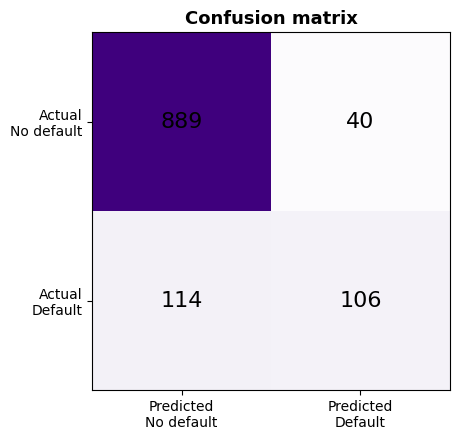

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(cm, cmap="Purples")
labels = ["No default", "Default"]
ax.set_xticks([0, 1], labels=[f"Predicted\n{l}" for l in labels])
ax.set_yticks([0, 1], labels=[f"Actual\n{l}" for l in labels])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=16)
ax.set_title("Confusion matrix", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Key Takeaways

Here is what we accomplished in Module 1:

1. **NEXUS speaks sklearn** — `fit()` and `predict()` work exactly as you expect. No new interface to learn.

2. **Training is remote** — your data is uploaded to Fundamental's cloud, NEXUS adapts to it, and you get back a model ID. You are not running a local grid search or hyperparameter sweep.

3. **The model ID is your permanent artifact** — save `nexus.trained_model_id_`. In Module 2, we load this model into a fresh `NEXUSClassifier` instance via `clf.load_model(MODEL_ID)` — no retraining required.

4. **Numeric features only in Module 1** — we deliberately started with four clean columns. In Module 3, we add the categorical columns plus a date-derived numeric feature, and walk through the patterns NEXUS expects.

5. **fit() blocks by default** — the synchronous call waits for training to complete. In Module 5, we swap this for the async `submit_fit_task` / `poll_fit_result` pattern, essential when you cannot block your production process.

---

## What's Next: Module 2

In Module 2 we take the model we just trained and squeeze more value out of it:

- `predict_proba()` to build a risk-ranked borrower list instead of hard binary labels
- `clf.load_model(MODEL_ID)` to reload your trained model across sessions without retraining
- `quality` vs `speed` mode compared side-by-side on real data
- Threshold tuning to dial in the precision/recall balance for a credit risk context

Your `MODEL_ID` is saved to the workshop state file on your Google Drive, so the next module picks it up automatically — each notebook runs in its own Colab session, and Drive is what carries state between them. (If you skipped the Drive mount, copy the printed `MODEL_ID` — Module 2 will ask you to paste it.)